# HydroSense-Kenya — Level 2
**ICS 2207 Scientific Computing**

Level 2: NumPy, Vectorization, Floating Point Errors, and Numerical Reliability

## Overview

In Level 1 we wrote the evapotranspiration function using plain Python. In this level we look at two things: first, how NumPy vectorization makes the same computation much faster, and second, how floating point limitations and measurement noise can affect the reliability of our results.

This matters in irrigation systems because decisions based on slightly wrong ET estimates can lead to either wasting water or stressing crops.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import warnings
warnings.filterwarnings('ignore')

print('libraries loaded')

libraries loaded


## Load Data

We load the same raw weather dataset from Level 1 and fill missing values temporarily so the ET formula does not crash.

In [2]:
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA', ''])
weather['date'] = pd.to_datetime(weather['date'])

# temporary fill for missing values — proper cleaning is in Level 4
weather_filled = weather.copy()
weather_filled[['temperature_c', 'wind_speed_mps', 'solar_index', 'humidity_pct']] = (
    weather_filled[['temperature_c', 'wind_speed_mps', 'solar_index', 'humidity_pct']]
    .ffill().bfill()
)

print('rows loaded:', len(weather_filled))

rows loaded: 30


## Task 1 — Loop-Based ET Computation

This is the same approach from Level 1 — iterating through each row using a for loop. We time it so we can compare it against the vectorized version.

In [3]:
def evapotranspiration(T, W, Solar, H):
    """
    Simplified ET estimate in mm/day.
    ET = max(0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)
    """
    return max(0.0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)


start = time.time()

et_loop = []
for _, row in weather_filled.iterrows():
    et = evapotranspiration(
        T=row['temperature_c'],
        W=row['wind_speed_mps'],
        Solar=row['solar_index'],
        H=row['humidity_pct']
    )
    et_loop.append(et)

loop_time = time.time() - start

print('loop time:', round(loop_time, 6), 'seconds')
print('first 5 ET values:', [round(x, 3) for x in et_loop[:5]])

loop time: 0.003657 seconds
first 5 ET values: [3.783, 3.829, 4.144, 3.748, 3.631]


## Task 2 — Vectorized ET Using NumPy

Instead of looping row by row, NumPy applies the formula to the entire column at once. The key difference is replacing Python's `max(0, ...)` with `np.maximum(0, ...)` which works element-wise on arrays.

In [4]:
start = time.time()

T      = weather_filled['temperature_c'].values
W      = weather_filled['wind_speed_mps'].values
Solar  = weather_filled['solar_index'].values
H      = weather_filled['humidity_pct'].values

et_vec = np.maximum(0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)

vec_time = time.time() - start

print('vectorized time:', round(vec_time, 6), 'seconds')
print('first 5 ET values:', [round(x, 3) for x in et_vec[:5]])

vectorized time: 0.000673 seconds
first 5 ET values: [np.float64(3.783), np.float64(3.829), np.float64(4.144), np.float64(3.748), np.float64(3.631)]


## Task 3 — Timing Comparison

We compare execution time and verify both methods give the same results.

In [5]:
results_match = np.allclose(et_loop, et_vec)

print('--- Timing Comparison ---')
print('Loop time:       ', round(loop_time, 6), 's')
print('Vectorized time: ', round(vec_time, 6), 's')
if loop_time > 0 and vec_time > 0:
    print('Speedup:         ', round(loop_time / vec_time, 2), 'x faster')
print('Results match:   ', results_match)
print()
print('On a 30-row dataset the difference is small, but on a dataset with')
print('thousands of sensor readings the vectorized approach would be significantly faster.')

--- Timing Comparison ---
Loop time:        0.003657 s
Vectorized time:  0.000673 s
Speedup:          5.44 x faster
Results match:    True

On a 30-row dataset the difference is small, but on a dataset with
thousands of sensor readings the vectorized approach would be significantly faster.


## Task 4 — Floating Point Behaviour

Computers store numbers in binary format, which means some decimal values cannot be represented exactly. This causes small but sometimes important errors in scientific computations.

In [6]:
# classic floating point example
print('0.1 + 0.2 =', 0.1 + 0.2)
print('0.1 + 0.2 == 0.3:', 0.1 + 0.2 == 0.3)
print()

# rounding error accumulation
total = 0.0
for _ in range(100):
    total += 0.1
print('0.1 added 100 times:', total)
print('expected 10.0, difference:', abs(total - 10.0))
print()

# float32 vs float64 precision
val32 = np.float32(1e8) + np.float32(1) - np.float32(1e8)
val64 = np.float64(1e8) + np.float64(1) - np.float64(1e8)
print('float32 result (1e8 + 1 - 1e8):', val32, '  <- precision lost')
print('float64 result (1e8 + 1 - 1e8):', val64, '  <- correct')
print()

# overflow
print('float64 overflow (1e308 * 10):', 1e308 * 10)

0.1 + 0.2 = 0.30000000000000004
0.1 + 0.2 == 0.3: False

0.1 added 100 times: 9.99999999999998
expected 10.0, difference: 1.9539925233402755e-14

float32 result (1e8 + 1 - 1e8): 0.0   <- precision lost
float64 result (1e8 + 1 - 1e8): 1.0   <- correct

float64 overflow (1e308 * 10): inf


### What this means for our irrigation model

- `0.1 + 0.2` does not equal `0.3` exactly because binary cannot represent 0.1 precisely. This is why we should never use `==` to compare floats — use `np.isclose()` instead.
- Adding 0.1 one hundred times accumulates a small error. In a 30-day simulation running many calculations this kind of drift can add up.
- `float32` loses precision much faster than `float64`. NumPy defaults to `float64` which is safer for scientific work.
- Overflow produces `inf`, which would completely break the water balance model if it happened inside a simulation loop.

## Task 5 — Error Propagation Experiment

In real farms, sensors are not perfectly accurate. Temperature sensors can have measurement errors of 0.5°C to 2°C or more. Here we simulate what happens to our ET estimates when we add increasing levels of noise to the temperature readings.

In [7]:
np.random.seed(42)
noise_levels = [0, 0.5, 1.0, 2.0, 5.0]  # standard deviation in degrees C

T_base  = weather_filled['temperature_c'].values
W_base  = weather_filled['wind_speed_mps'].values
S_base  = weather_filled['solar_index'].values
H_base  = weather_filled['humidity_pct'].values

et_results = []
for sigma in noise_levels:
    T_noisy = T_base + np.random.normal(0, sigma, len(T_base))
    et = np.maximum(0, 0.12*T_noisy + 0.35*W_base + 2.4*S_base - 0.025*H_base)
    et_results.append(et)

print('mean ET by noise level:')
for sigma, et in zip(noise_levels, et_results):
    print(f'  noise={sigma} C  ->  mean ET={round(et.mean(), 4)} mm/day')

mean ET by noise level:
  noise=0 C  ->  mean ET=3.7489 mm/day
  noise=0.5 C  ->  mean ET=3.7416 mm/day
  noise=1.0 C  ->  mean ET=3.7504 mm/day
  noise=2.0 C  ->  mean ET=3.744 mm/day
  noise=5.0 C  ->  mean ET=3.6919 mm/day


### Error Propagation Plot

The plot below shows how ET estimates spread out as sensor noise increases. Each line represents one noise level — wider spread means less reliable irrigation decisions.

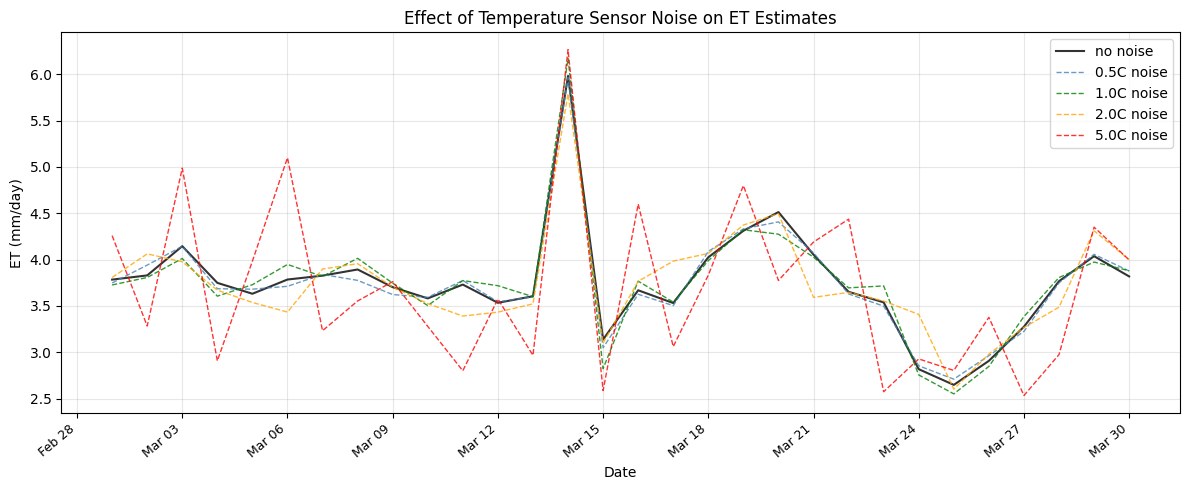

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['black', 'steelblue', 'green', 'orange', 'red']
labels = ['no noise', '0.5C noise', '1.0C noise', '2.0C noise', '5.0C noise']

for et, color, label in zip(et_results, colors, labels):
    ax.plot(weather_filled['date'], et, color=color,
            linewidth=1.5 if label == 'no noise' else 1,
            linestyle='-' if label == 'no noise' else '--',
            label=label, alpha=0.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)

ax.set_title('Effect of Temperature Sensor Noise on ET Estimates')
ax.set_xlabel('Date')
ax.set_ylabel('ET (mm/day)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/error_propagation_plot.png', dpi=150)
plt.show()

## Task 6 — Numerical Reliability Discussion

This experiment shows that even small sensor errors have a real effect on ET estimates. With 2°C of noise the ET values vary noticeably from the true estimate, and with 5°C of noise the estimates become unreliable enough that irrigation decisions based on them could be significantly wrong.

In practice this means:
- Sensor calibration matters. A poorly calibrated temperature sensor does not just give wrong temperature readings — it affects every downstream calculation that uses temperature, including ET, water balance, and irrigation scheduling.
- We should not treat computed ET values as exact. They are estimates with uncertainty, and that uncertainty should inform how aggressively we act on them.
- Floating point errors are separate from sensor errors but compound the same problem. Using `float64` and avoiding equality comparisons on floats reduces numerical noise from the computation itself.

The key takeaway is that scientific computing is not just about getting a number — it is about understanding how reliable that number is.

## Level 2 Summary

| Task | Done |
|------|------|
| ET computed using Python loop | yes |
| ET computed using NumPy vectorization | yes |
| Timing comparison | yes |
| Floating point behaviour demonstrated | yes |
| Error propagation experiment | yes |
| Numerical reliability discussion | yes |
